# California at o8 — the fat-tail campaign (appendix)

The full o8 state run and its forensics, moved out of `02_write` (which now runs California at o9): the $35 ceiling and $19 actual, the 63-shard fat tail, the `8192-disk` heal (53 recovered), the semantic-identity guardrails that shaped the healing options, and the o9 recast experiment proving the ten survivors were border-overhang shards that fit the standard tier at production order (max 3.6 GB, 343 s). Kept as the worked example of per-shard telemetry, surgical redispatch, and tier laddering.

In [1]:
# %pip install "zagg[catalog,viz]"

import io
import json
import logging
import os
import time
from pathlib import Path

import boto3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

from zagg.catalog.shardmap import ShardMap
from zagg.client import Run
from zagg.config import default_config
from zagg.notebook import format_max_cost, max_cost_preview

In [2]:
# prefer the 'nasa' profile when it exists (laptop); ambient creds otherwise (hub role)
import botocore.session as _bs

if "nasa" in (_bs.Session().full_config.get("profiles") or {}):
    os.environ.setdefault("AWS_PROFILE", "nasa")
logging.basicConfig(level=logging.INFO, format="%(name)s: %(message)s")
for noisy in ("botocore", "boto3", "urllib3", "s3transfer", "stac_geoparquet"):
    logging.getLogger(noisy).setLevel(logging.WARNING)

OUT = Path("outputs")
STORE = "s3://sliderule-public/zagg-demo"

timings = {}


class stage:
    def __init__(self, name):
        self.name = name

    def __enter__(self):
        self.t0 = time.perf_counter()
        return self

    def __exit__(self, *exc):
        timings[self.name] = round(time.perf_counter() - self.t0, 2)
        print(f"[{self.name}] {timings[self.name]:.1f}s")

## California at o8 — cost ceiling, first-shard latency, actuals

The full production shape at state scale: the **strata (signal/noise, located)** aggregation — two `build_tdigest_where` digests split by the per-surface confidence union, each with a morton location channel, plus the packed `composition` lanes — on hive + sharded o8 shards, `process-shard-4096-disk` with spill, and the **sidecar** chunk-index in write-through mode (`on_miss: build`). The store is **kept**, never wiped — rerun to a fresh store path and compare wall/cost against the reported run to see the warm-index difference. (Hive leaves also write D20 stats sidecars — telemetry, unrelated to the chunk-index.)

In [28]:
ca_config = default_config("atl03_tdigest_strata_healpix")
ca_config.output = default_config(
    "atl03_tdigest_healpix_hive"
).output  # hive + sharded + pyramid off
ca_config.output["grid"]["parent_order"] = 8
ca_config.worker = dict(default_config("atl03_tdigest_healpix_hive").worker)  # 4096-disk
ca_config.aggregation["streaming"] = {"mode": "spill"}
# write-through sidecar chunk-index: this run stores a per-granule index manifest
# as it reads; a repeat run over the same granules skips the metadata walk
ca_config.data_source["index"] = {
    "backend": "sidecar",
    "on_miss": "build",
    "store": "s3://sliderule-public-cors/zagg-index/ATL03/007",
}
ca_map = str(OUT / "shardmap_california_o8.json")

print(format_max_cost(max_cost_preview(ca_config, catalog=ca_map)))

Max cost ceiling: ~$35.09 (731 units x 4 GB x 900s, arm64)


In [29]:
# KEPT across sessions (never wiped). Repeat runs: point at a fresh path -- the
# reported store stays, and the warmed sidecar index speeds the repeat either way.
CA_STORE = f"{STORE}/california_tdigest_o8.zarr"

run_ca = Run.from_config(ca_config, shardmap=ca_map, store=CA_STORE, overwrite=True)

t0 = time.perf_counter()
handle_ca = run_ca.dispatch()
completions = []
with stage("California: o8 run"):
    for fut in handle_ca.progress():
        completions.append(time.perf_counter() - t0)
print(
    f"first shard done at {completions[0]:.1f}s; "
    f"full state at {completions[-1]:.1f}s ({len(completions)} shards)"
)

zagg.runner: Account concurrency: limit=2000, current=2, padding=100, available=1898 -> using 731 workers
zagg.client: Max cost ceiling: ~$35.09 (731 units x 4 GB x 900s, arm64)
zagg.runner: Preflight OK (function zagg version 0.0.0+unknown)


shards:   0%|          | 0/731 [00:00<?, ?shard/s]

zagg.runner: run stats rows (731) exceed the async payload budget and this sync run has no status prefix to point at; skipping (fail-open, issue #313)


[California: o8 run] 904.9s
first shard done at 134.9s; full state at 912.7s (731 shards)


Per-shard telemetry lands as a parquet at the store root (one row per shard: durations, phase timings, observation counts, priced GB-seconds).

In [33]:
from zagg import runner as _runner
from zagg.client import ShardError


def _handle_results(handle):
    """Every shard's result dict -- worker envelopes, ShardError payloads, or a
    synthesized failure row -- exactly the tail's own accounting (issue #333)."""
    out = []
    for key, fut in handle.futures.items():
        exc = fut.exception()
        if exc is None:
            out.append(fut.result())
        elif isinstance(exc, ShardError):
            out.append(exc.payload)
        else:
            out.append(
                {
                    "shard_key": key,
                    "status_code": None,
                    "body": {},
                    "error": f"{type(exc).__name__}: {exc}",
                    "retries": None,
                }
            )
    return out


def fetch_run_stats(store_path, handle=None):
    """Run-stats rows: the store parquet when present, else rebuilt from the handle.

    A v1 sync-transport run above the async payload budget (~500 shards) skips
    its store-root parquet -- no status prefix to point at (issues #313/#327);
    the identical rows are reconstructed from the in-memory futures instead.
    An event-transport run always lands the parquet.
    """
    bucket, _, prefix = store_path.removeprefix("s3://").partition("/")
    s3 = boto3.client("s3")
    objs = s3.list_objects_v2(Bucket=bucket, Prefix=f"{prefix}/stats_").get("Contents", [])
    if objs:
        key = max(o["Key"] for o in objs)  # timestamp-first names sort chronologically
        return pq.read_table(
            io.BytesIO(s3.get_object(Bucket=bucket, Key=key)["Body"].read())
        ).to_pandas()
    assert handle is not None, "no stats parquet at the store root and no handle to rebuild from"
    rows, _inline = _runner._lambda_result_rows(_handle_results(handle), run_id="notebook-rebuild")
    return pd.DataFrame(rows)


from zagg.dispatch import LAMBDA_PRICE_PER_GB_SEC

stats = fetch_run_stats(handle_ca.store_path, handle=handle_ca)
ok = stats[stats.success.fillna(False)]
fails = stats[~stats.success.fillna(False)]
# failure rows carry duration (billed until the kill) but no worker-priced cost
# fields -- price them at the run's memory so the billed estimate is honest
memory_gb = _runner._worker_memory_gb(ca_config)
billed = stats.est_cost_usd.fillna(stats.duration_s * memory_gb * LAMBDA_PRICE_PER_GB_SEC).sum()
print(
    f"worker-reported cost ${stats.est_cost_usd.sum():.2f}; billed estimate incl. "
    f"{len(fails)} failed attempts ${billed:.2f} | "
    f"{stats.duration_s.sum():,.0f} lambda-seconds, {ok.n_obs.sum() / 1e9:.2f}B photons"
)
if len(fails):
    print("failure classes:")
    print(fails.error_class.str[:60].value_counts().to_string())
stats[["duration_s", "n_obs", "n_granules", "gb_seconds", "est_cost_usd"]].describe().round(4)

worker-reported cost $18.99; billed estimate incl. 63 failed attempts $19.50 | 365,628 lambda-seconds, 31.93B photons
failure classes:
error_class
Lambda OOM    63


,duration_s,n_obs,n_granules,gb_seconds,est_cost_usd
count,731.0000,7.310000e+02,731.0000,668.0000,668.0000
mean,500.1746,4.368630e+07,96.5075,2132.2467,0.0284
std,133.4200,1.866589e+07,31.6493,332.0996,0.0044
min,127.1724,0.000000e+00,0.0000,1374.6334,0.0183
25%,468.1175,3.524503e+07,100.0000,1924.7409,0.0257
50%,510.4595,4.582772e+07,109.0000,2063.9177,0.0275
75%,554.7952,5.561215e+07,112.0000,2247.6072,0.0300
max,835.6760,9.350695e+07,123.0000,3342.7042,0.0446


Fat-tail healing: an OOM'd shard reruns alone on the `8192-disk` tier. Worker sizing is outside the semantic core, so the manifest accepts the redispatch and the hive leaf overwrite is surgical — one leaf, nothing else touched.

In [34]:
failed = [k for k, f in handle_ca.futures.items() if f.exception() is not None]
if not failed:
    print("no failed shards -- nothing to heal")
else:
    heal_config = default_config("atl03_tdigest_strata_healpix")
    heal_config.output = default_config("atl03_tdigest_healpix_hive").output
    heal_config.output["grid"]["parent_order"] = 8
    heal_config.worker = {"memory": 8192, "extra_disk": True}  # process-shard-8192-disk
    heal_config.aggregation["streaming"] = {"mode": "spill"}
    heal_config.data_source["index"] = dict(ca_config.data_source["index"])

    run_heal = Run.from_config(heal_config, shardmap=ca_map, store=CA_STORE, overwrite=True)
    with stage(f"California: heal {len(failed)} shard(s) on 8192-disk"):
        handle_heal = run_heal.dispatch(shard_keys=failed)
        for fut in handle_heal.progress():
            pass
    print(f"healed: {handle_heal.status()} -- metered ${handle_heal.cost_usd():.4f}")
    print("note: the stats frame above still shows the first attempt's failure row")

zagg.runner: Account concurrency: limit=2000, current=0, padding=100, available=1900 -> using 63 workers
zagg.client: Max cost ceiling: ~$6.05 (63 units x 8 GB x 900s, arm64)
zagg.runner: Preflight OK (function zagg version 0.0.0+unknown)


shards:   0%|          | 0/63 [00:00<?, ?shard/s]

zagg.runner: Dispatched run stats write (63 rows, fire-and-forget): s3://sliderule-public/zagg-demo/california_tdigest_o8.zarr/stats_20260804T035853Z_8b9838e1c174431b8989eced332ae63a.parquet


[California: heal 63 shard(s) on 8192-disk] 914.8s
healed: {'pending': 0, 'ok': 53, 'failed': 10} -- metered $3.3279
note: the stats frame above still shows the first attempt's failure row


In [35]:
heal_stats = fetch_run_stats(CA_STORE, handle=handle_heal)
hf = heal_stats[~heal_stats.success.fillna(False)]
print(hf.error_class.value_counts().to_string())

import json as _json

_m = _json.load(open(ca_map))
_gc = {k: len(g) for k, g in zip(_m["shard_keys"], _m["granules"])}
hf = hf.assign(granules_in_map=hf.shard_key.map(_gc))
print(hf[["shard_key", "duration_s", "granules_in_map"]].to_string(index=False))

heal_stats[["duration_s", "max_memory_mb", "container_hwm_mb", "n_obs"]].describe().round(1)

error_class
Lambda OOM        7
Lambda timeout    3
          shard_key  duration_s  granules_in_map
3909317990604079112   89.502577              109
3909810571813322760  904.826681              113
3909757795255189512  120.973007              108
3911393868557320200  110.904073              111
3911534606045675528  124.202346              109
3909898532743544840  111.298425              106
3911481829487542280  111.804349              109
3910109638976077832  904.748164              113
3911622566975897608  118.607961               99
3911640159161942024  904.694290              117


,duration_s,max_memory_mb,container_hwm_mb,n_obs
count,63.0,53.0,53.0,63.0
mean,550.8,5178.8,5182.4,88930628.3
std,186.8,976.7,975.6,45065859.4
min,89.5,4151.4,4152.9,0.0
25%,514.3,4415.2,4416.0,81163602.5
50%,561.9,4902.8,4904.1,94773338.0
75%,635.2,5498.5,5498.5,113500421.5
max,904.8,8062.3,8062.5,182908443.0


The 10 survivors, recast: their o9 children on the **standard** `4096-disk` tier, into a separate o9 store (a finer shard order can't share the o8 manifest). o9 cells are ¼ the area, so each monster becomes ≤16 normal-sized shards — this tests whether the standard size accommodates the Sierra crest, and whether the three 900 s deaths were true time-wall or memory-thrash masquerading as timeout: if their children sail through at o9/4 GB, it was resource exhaustion either way.

In [36]:
from mortie import generate_morton_children

failed2 = sorted(int(k) for k, f in handle_heal.futures.items() if f.exception() is not None)
sm_o9_keys = {
    int(k) for k in ShardMap.from_json(str(OUT / "shardmap_california_o9.json")).shard_keys
}
children = [c for k in failed2 for c in map(int, generate_morton_children(k, 9)) if c in sm_o9_keys]
print(f"{len(failed2)} failed o8 shards -> {len(children)} mapped o9 children")

tail_config = default_config("atl03_tdigest_strata_healpix")
tail_config.output = default_config("atl03_tdigest_healpix_hive").output  # parent_order 9
tail_config.worker = {"memory": 4096, "extra_disk": True}  # the standard tier
tail_config.aggregation["streaming"] = {"mode": "spill"}
tail_config.data_source["index"] = dict(ca_config.data_source["index"])

run_tail = Run.from_config(
    tail_config,
    shardmap=str(OUT / "shardmap_california_o9.json"),
    store=f"{STORE}/california_tail_o9.zarr",
    overwrite=True,
)
with stage(f"Sierra tail at o9 on 4096-disk ({len(children)} shards)"):
    handle_tail = run_tail.dispatch(shard_keys=children)
    for fut in handle_tail.progress():
        pass
print(f"{handle_tail.status()} -- metered ${handle_tail.cost_usd():.4f}")

10 failed o8 shards -> 40 mapped o9 children


zagg.runner: Account concurrency: limit=2000, current=0, padding=100, available=1900 -> using 40 workers
zagg.client: Max cost ceiling: ~$1.92 (40 units x 4 GB x 900s, arm64)
zagg.runner: Preflight OK (function zagg version 0.0.0+unknown)


shards:   0%|          | 0/40 [00:00<?, ?shard/s]

zagg.runner: Dispatched run stats write (40 rows, fire-and-forget): s3://sliderule-public/zagg-demo/california_tail_o9.zarr/stats_20260804T041850Z_d5b7e2f1ca1d41cb8ab5c21b1c730e34.parquet


[Sierra tail at o9 on 4096-disk (40 shards)] 375.5s
{'pending': 0, 'ok': 40, 'failed': 0} -- metered $0.4902


In [37]:
tail_stats = fetch_run_stats(handle_tail.store_path, handle=handle_tail)
tfail = tail_stats[~tail_stats.success.fillna(False)]
print(f"{int(tail_stats.success.sum())}/{len(tail_stats)} ok at o9 on the standard tier")
if len(tfail):
    print(tfail.error_class.value_counts().to_string())
tail_stats[["duration_s", "max_memory_mb", "n_obs"]].describe().round(1)

40/40 ok at o9 on the standard tier


,duration_s,max_memory_mb,n_obs
count,40.0,40.0,40.0
mean,229.8,2232.2,40484242.1
std,42.8,653.9,14436890.4
min,157.4,1058.1,13875743.0
25%,196.4,1656.2,30220371.5
50%,221.7,2160.6,37808317.0
75%,254.1,2721.0,52594749.8
max,342.8,3638.4,72161568.0


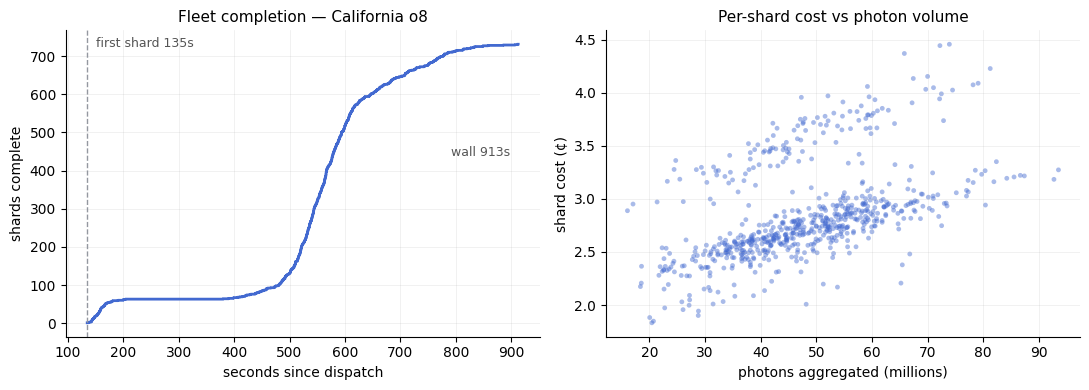

In [38]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

t = np.asarray(completions)
n = np.arange(1, len(t) + 1)
ax1.step(t, n, where="post", color="#4269d0", lw=2)
ax1.axvline(t[0], color="#9498a0", lw=1, ls="--")
ax1.annotate(
    f"first shard {t[0]:.0f}s",
    (t[0], len(t)),
    xytext=(6, -2),
    textcoords="offset points",
    fontsize=9,
    color="#555",
)
ax1.annotate(
    f"wall {t[-1]:.0f}s",
    (t[-1], len(t) * 0.6),
    xytext=(-6, 0),
    textcoords="offset points",
    ha="right",
    fontsize=9,
    color="#555",
)
ax1.set_xlabel("seconds since dispatch")
ax1.set_ylabel("shards complete")
ax1.set_title("Fleet completion — California o8", fontsize=11)

ax2.scatter(
    stats.n_obs / 1e6,
    stats.est_cost_usd * 100,
    s=12,
    alpha=0.45,
    color="#4269d0",
    edgecolors="none",
)
ax2.set_xlabel("photons aggregated (millions)")
ax2.set_ylabel("shard cost (¢)")
ax2.set_title("Per-shard cost vs photon volume", fontsize=11)

for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.25, lw=0.5)
plt.tight_layout()

Per-shard distributions and the run rollup — including how many shards entered the spill fold regime (`spill_blocks_closed`, issue #370).

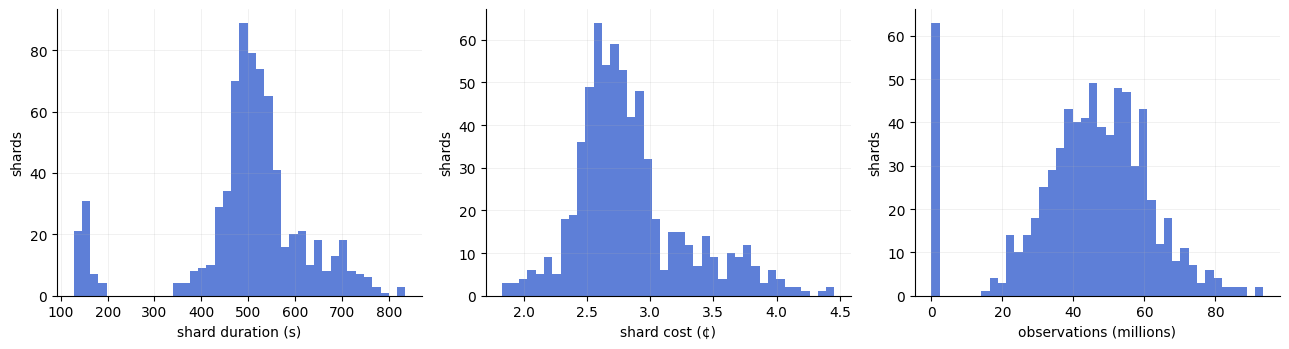

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
panels = [
    ("duration_s", "shard duration (s)", 1.0),
    ("est_cost_usd", "shard cost (\u00a2)", 100.0),
    ("n_obs", "observations (millions)", 1e-6),
]
for ax, (col, label, scale) in zip(axes, panels):
    ax.hist(stats[col].dropna() * scale, bins=40, color="#4269d0", alpha=0.85)
    ax.set_xlabel(label)
    ax.set_ylabel("shards")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.25, lw=0.5)
plt.tight_layout()

In [40]:
folded = stats.get("spill_blocks_closed")
run_summary = {
    "shards": len(stats),
    "succeeded": int(stats.success.sum()),
    "total_obs": f"{int(stats.n_obs.sum()):,}",
    "granule reads": f"{int(stats.n_granules.sum()):,}",
    "lambda-seconds": f"{stats.duration_s.sum():,.0f}",
    "actual cost (USD)": round(float(stats.est_cost_usd.sum()), 2),
    "duration s (median / p95 / max)": f"{stats.duration_s.median():.0f} / {stats.duration_s.quantile(0.95):.0f} / {stats.duration_s.max():.0f}",
    "obs per shard (median / max)": f"{stats.n_obs.median():,.0f} / {stats.n_obs.max():,.0f}",
    "spill fold regime (shards)": int((folded.fillna(0) > 0).sum())
    if folded is not None
    else "n/a (pre-#370 worker)",
    "wall s (first / last shard)": f"{completions[0]:.0f} / {completions[-1]:.0f}",
}
pd.Series(run_summary, name="California o8").to_frame()

,California o8
shards,731
succeeded,668
total_obs,"31,934,683,091"
granule reads,"70,547"
lambda-seconds,"365,628"
actual cost (USD),18.99
duration s (median / p95 / max),510 / 702 / 836
obs per shard (median / max),"45,827,721 / 93,506,946"
spill fold regime (shards),0
wall s (first / last shard),135 / 913


## Timings

In [ ]:
(OUT / "timings_california_o8.json").write_text(json.dumps(timings, indent=2))
pd.Series(timings, name="seconds").to_frame()